In [39]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

# *Settings for plotting graphs*

In [40]:
sns.set_style("darkgrid")
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10,6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

# *Downloading Data from url*

In [41]:
from urllib.request import urlretrieve

In [42]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [43]:
urlretrieve(medical_charges_url,'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x25c33dbb9b0>)

In [44]:
medical_df = pd.read_csv("medical.csv")

In [45]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [46]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [47]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [48]:
fig = px.histogram(medical_df, 
                   x='age', 
                   marginal='box', 
                   nbins=47, 
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

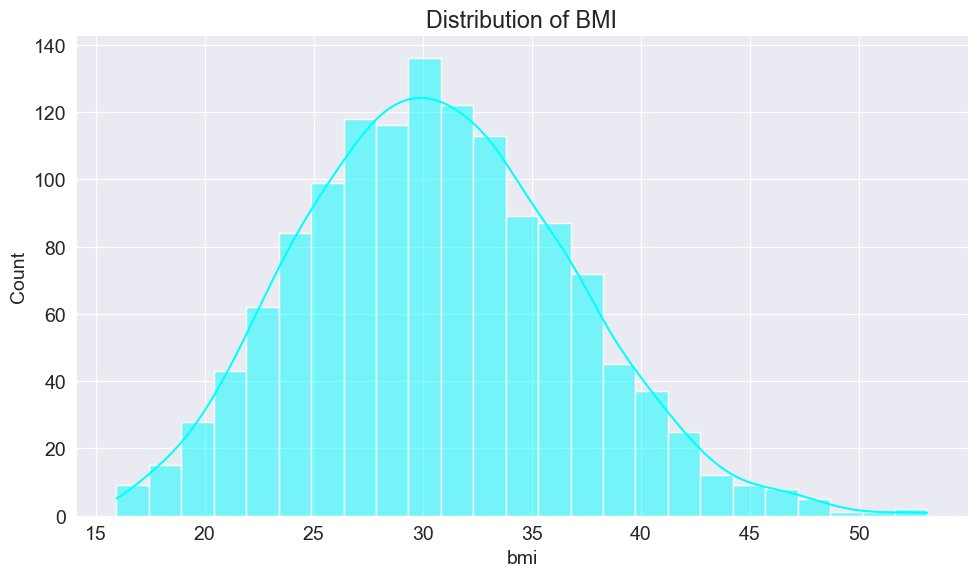

In [49]:
sns.histplot(data= medical_df,x='bmi',kde=True,color='cyan')
plt.title("Distribution of BMI")
plt.tight_layout()
plt.show()

*Note*

*-> The age is mostly a uniform distribution except for the age grp btw 18-20 may be due insurance is given to above 18 only or maybe 18-20 age grp is mostly likely not to claim the insurance very eraly.*

*-> But BMI is normaly distributed with mean around 27.5 - 32.5 which are people in overwight or obese category.*

In [50]:
# Plot for charges vs smoker
fig = px.histogram(medical_df,x="charges",marginal="box",color="smoker",color_discrete_sequence=["cyan","orange"],title="Yearly Medical Charges")
fig.update_layout(bargap=0.1)
fig.show()

In [51]:
# Plot for charges vs sex
fig = px.histogram(medical_df,x="charges",marginal="box",color="sex",color_discrete_sequence=["cyan","orange"],title="Yearly Medical Charges")
fig.update_layout(bargap=0.1)
fig.show()

In [52]:
# Plot for charges vs region
fig = px.histogram(medical_df,x="charges",marginal="box",color="region",color_discrete_sequence=["cyan","orange","green","yellow"],title="Yearly Medical Charges")
fig.update_layout(bargap=0.1)
fig.show()

# *Analysis on Smoker Col*

In [53]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

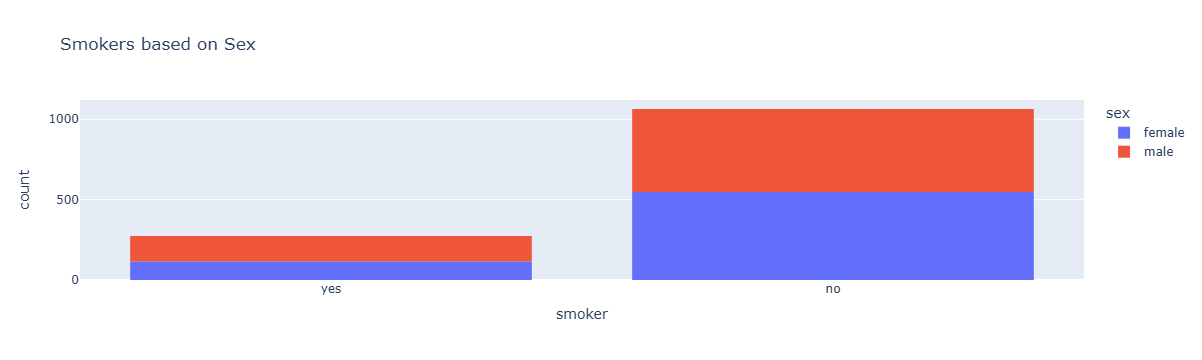

In [68]:
px.histogram(medical_df,x="smoker",color="sex",title="Smokers based on Sex")

In [62]:
total = medical_df["smoker"].value_counts().sum()
print(f"The percentage of Smokers {((medical_df["smoker"]=="yes").sum()/total)*100:.4f}%")

The percentage of Smokers 20.4783%


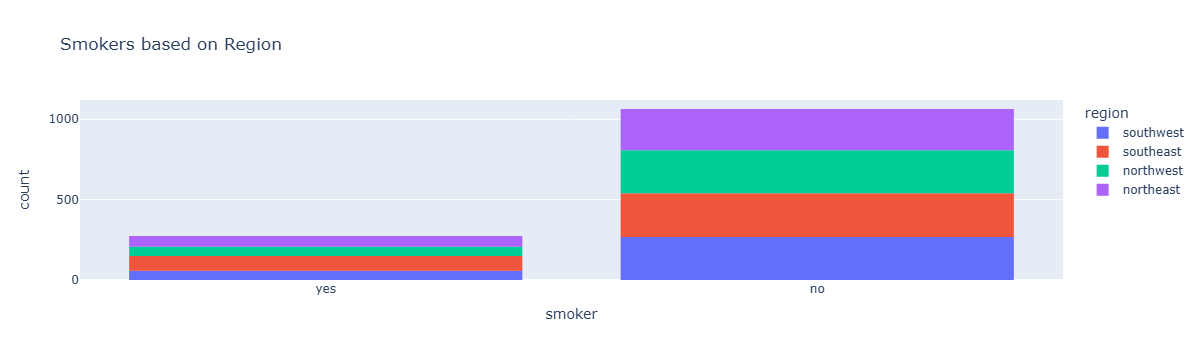

In [69]:
px.histogram(medical_df,x="smoker",color="region",title="Smokers based on Region")

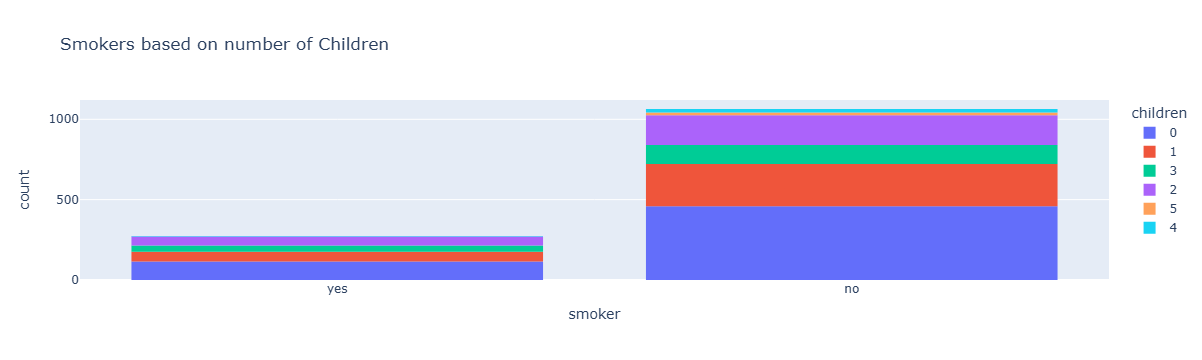

In [72]:
px.histogram(medical_df,x="smoker",color="children",title="Smokers based on number of Children")

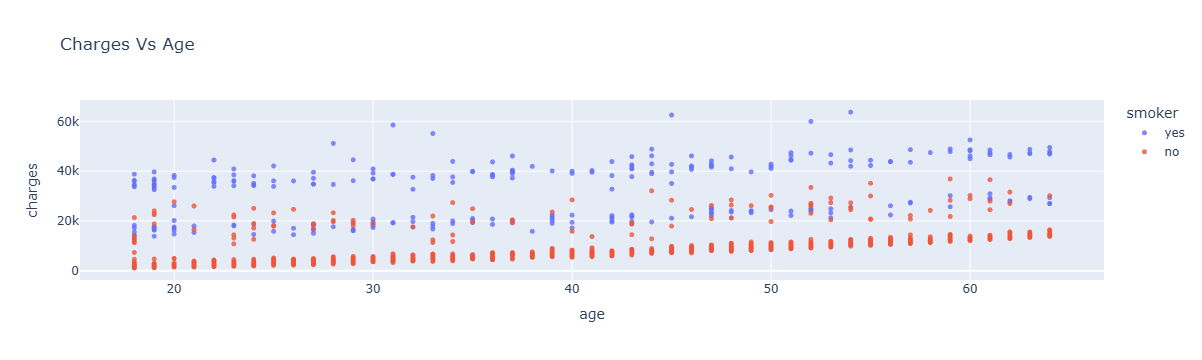

In [79]:
fig = px.scatter(medical_df,x="age",y="charges",color="smoker",opacity=0.8,hover_data=["sex"],title="Charges Vs Age")
fig.update_traces(marker_size=5)
fig.show()

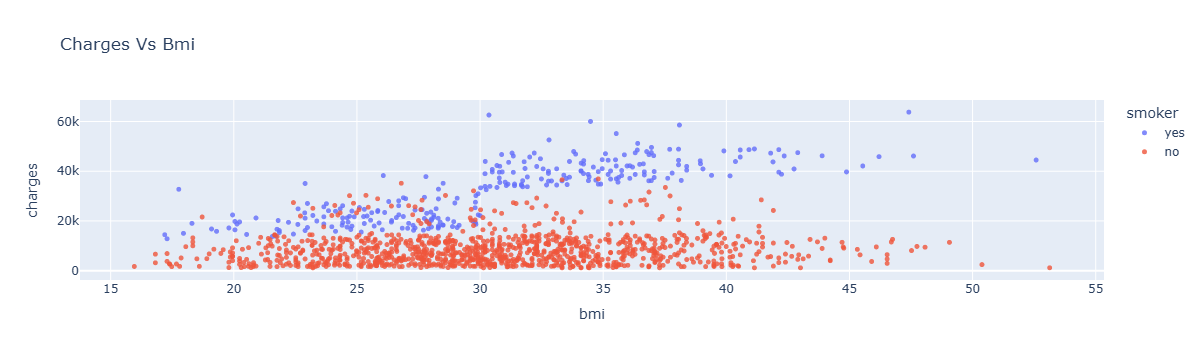

In [78]:
fig = px.scatter(medical_df,x="bmi",y="charges",color="smoker",opacity=0.8,hover_data=["sex"],title="Charges Vs Bmi")
fig.update_traces(marker_size=5)
fig.show()

# *Correlation btw Features*

## *for numerical featueres*

In [83]:
# Correlation btw charges and age
medical_df.charges.corr(medical_df.age)

0.2990081933306478

In [84]:
# Correlation btw charges and bmi
medical_df.charges.corr(medical_df.bmi)

0.19834096883362887

In [85]:
# Correlation btw charges and children
medical_df.charges.corr(medical_df.children)

0.06799822684790487

***so from above the most strong feature is age then bmi then children(weak correlation)***

## *for categorical featueres*

In [91]:
#for smoker col
smoker_val = {"no":0,"yes":1}
smoker = medical_df.smoker.map(smoker_val)
medical_df.charges.corr(smoker)

0.7872514304984778

In [92]:
#for region col
region_val = {"southwest":1,"southeast":2,"northwest":3,"northeast":4}
region = medical_df.region.map(region_val)
medical_df.charges.corr(region)

0.006208234909444472

In [94]:
#for sex col
sex_val = {"female":0,"male":1}
sex = medical_df.sex.map(sex_val)
medical_df.charges.corr(sex)

0.05729206220202533

***So in total the final order of importance of features is: smoker(strong) -> age -> bmi -> children -> sex -> region(weak) & all are positivly correlated.***

In [96]:
# Correlation table for numeric features
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000
